# ДЗ lesson 2: классификация AG News (baseline TextCNN)

Это первый подход к задаче. На семинаре разбирали TextCNN — повторил его и докрутил несколько улучшений:
- glove-100 вместо случайных эмбеддингов
- kernel sizes {2, 3, 4, 5} вместо {3, 4, 5}
- AdamW + cosine LR + label smoothing
- gradient clipping

Цель домашки — Macro F1 ≥ 0.95. На голом TextCNN до 0.95 не достать (как и говорилось на семинаре), но это хороший baseline, от которого дальше будем улучшать в `agnews_hybrid.ipynb`.

## 1. Импорты, сид

In [1]:
import os, re, time, random
from collections import Counter

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from datasets import load_dataset
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report

import matplotlib.pyplot as plt
import seaborn as sns
import gensim.downloader as api

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('device:', device)

device: cpu


## 2. Конфиг

In [2]:
MAX_LEN      = 96
MAX_VOCAB    = 40000
MIN_FREQ     = 2
BATCH_SIZE   = 256
EPOCHS       = 5
LR           = 1e-3
WD           = 1e-5
LABEL_SMOOTH = 0.1
DROPOUT      = 0.5
EMBED_NAME   = 'glove-wiki-gigaword-100'

CNN_KERNELS  = (2, 3, 4, 5)
CNN_FILTERS  = 100

GRAD_CLIP    = 1.0

## 3. Данные

In [3]:
try:
    ds = load_dataset('ag_news')
except Exception:
    ds = load_dataset('fancyzhx/ag_news')

X_train_full = list(ds['train']['text'])
y_train_full = list(ds['train']['label'])
X_test = list(ds['test']['text'])
y_test = list(ds['test']['label'])

X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full,
    test_size=0.1, random_state=SEED, stratify=y_train_full,
)

CLASSES = ['World', 'Sports', 'Business', 'Sci/Tech']
print(f'train={len(X_train)}  val={len(X_val)}  test={len(X_test)}')

train=108000  val=12000  test=7600


## 4. Токенизация и словарь

Простой `\w+` + lower. Числа маппим в `<num>` — на AG News с финансовыми заголовками это снижает число OOV.

In [4]:
TOK_RE = re.compile(r"\b\w+\b")
NUM_RE = re.compile(r'^\d+([.,]\d+)?$')
PAD, UNK, NUM = '<pad>', '<unk>', '<num>'
PAD_ID, UNK_ID, NUM_ID = 0, 1, 2

def tokenize(text):
    toks = TOK_RE.findall(text.lower())
    return [NUM if NUM_RE.match(t) else t for t in toks]

cnt = Counter()
for t in X_train:
    cnt.update(tokenize(t))

vocab = {PAD: PAD_ID, UNK: UNK_ID, NUM: NUM_ID}
for w, c in cnt.most_common():
    if c < MIN_FREQ or len(vocab) >= MAX_VOCAB:
        break
    if w not in vocab:
        vocab[w] = len(vocab)
print(f'словарь: {len(vocab)}')

словарь: 40000


## 5. GloVe-100

In [5]:
kv = api.load(EMBED_NAME)
EMBED_DIM = kv.vector_size

rng = np.random.default_rng(SEED)
E = rng.normal(0, 0.1, size=(len(vocab), EMBED_DIM)).astype(np.float32)
E[PAD_ID] = 0.0
hits = 0
for w, i in vocab.items():
    if i in (PAD_ID, UNK_ID, NUM_ID):
        continue
    if w in kv:
        E[i] = kv[w]; hits += 1
print(f'покрытие glove: {hits}/{len(vocab)-3} = {hits/(len(vocab)-3)*100:.2f}%')
E = torch.from_numpy(E)
del kv

покрытие glove: 38280/39997 = 95.71%


## 6. Dataset/DataLoader (с динамическим паддингом)

In [6]:
class AGN(Dataset):
    def __init__(self, X, y):
        self.X, self.y = X, y
    def __len__(self):
        return len(self.X)
    def __getitem__(self, i):
        ids = [vocab.get(t, UNK_ID) for t in tokenize(self.X[i])][:MAX_LEN]
        if not ids:
            ids = [UNK_ID]
        return torch.tensor(ids, dtype=torch.long), torch.tensor(self.y[i], dtype=torch.long)

def collate(batch):
    seqs, ys = zip(*batch)
    L = max(len(s) for s in seqs)
    out = torch.full((len(seqs), L), PAD_ID, dtype=torch.long)
    msk = torch.zeros((len(seqs), L), dtype=torch.bool)
    for i, s in enumerate(seqs):
        out[i, :len(s)] = s
        msk[i, :len(s)] = True
    return out, msk, torch.stack(ys)

train_ds = AGN(X_train, y_train); val_ds = AGN(X_val, y_val); test_ds = AGN(X_test, y_test)
nw = 0 if os.name == 'nt' else 4
train_dl = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=nw, collate_fn=collate)
val_dl   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=nw, collate_fn=collate)
test_dl  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=nw, collate_fn=collate)
print(f'батчей: train={len(train_dl)}  val={len(val_dl)}  test={len(test_dl)}')

батчей: train=422  val=47  test=30


## 7. TextCNN

Классика Kim (2014): несколько параллельных Conv1d с разными ядрами + max-over-time pooling + Linear. Маска нужна чтобы паддинг не лез в max-pool.

In [7]:
class TextCNN(nn.Module):
    def __init__(self, vocab_size, E=None):
        super().__init__()
        if E is not None:
            self.emb = nn.Embedding.from_pretrained(E, freeze=False, padding_idx=PAD_ID)
        else:
            self.emb = nn.Embedding(vocab_size, EMBED_DIM, padding_idx=PAD_ID)
        self.convs = nn.ModuleList([
            nn.Conv1d(EMBED_DIM, CNN_FILTERS, k, padding=k//2) for k in CNN_KERNELS
        ])
        self.do = nn.Dropout(DROPOUT)
        self.fc = nn.Linear(CNN_FILTERS * len(CNN_KERNELS), 4)

    def forward(self, x, mask):
        e = self.emb(x)                              # (B, T, D)
        ec = e.transpose(1, 2)                       # (B, D, T)
        mf = mask.unsqueeze(1).float()
        feats = []
        for conv in self.convs:
            h = F.relu(conv(ec))                     # (B, F, T')
            h = h[..., :mf.size(-1)]
            h = h.masked_fill(mf == 0, -1e4)
            feats.append(h.max(dim=2).values)
        z = torch.cat(feats, dim=1)
        return self.fc(self.do(z))

_m = TextCNN(len(vocab), E)
_x, _msk, _y = next(iter(train_dl))
with torch.no_grad():
    _o = _m(_x, _msk)
print('forward OK, logits:', tuple(_o.shape), '| params:', sum(p.numel() for p in _m.parameters()))
del _m, _x, _msk, _y, _o

forward OK, logits: (256, 4) | params: 4142004


## 8. Обучение

In [8]:
def run_epoch(model, loader, criterion, optimizer=None):
    is_train = optimizer is not None
    model.train(is_train)
    losses, preds, trues = [], [], []
    for x, msk, y in loader:
        x, msk, y = x.to(device), msk.to(device), y.to(device)
        with torch.set_grad_enabled(is_train):
            logits = model(x, msk)
            loss = criterion(logits, y)
        if is_train:
            optimizer.zero_grad(); loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
            optimizer.step()
        losses.append(loss.item())
        preds.append(logits.argmax(1).cpu().numpy())
        trues.append(y.cpu().numpy())
    p = np.concatenate(preds); t = np.concatenate(trues)
    return float(np.mean(losses)), accuracy_score(t, p), f1_score(t, p, average='macro')

model = TextCNN(len(vocab), E).to(device)
criterion = nn.CrossEntropyLoss(label_smoothing=LABEL_SMOOTH)
optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WD)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS, eta_min=LR*0.01)

history = {'tr_loss':[], 'tr_acc':[], 'tr_f1':[], 'val_loss':[], 'val_acc':[], 'val_f1':[]}
best_f1 = -1.0; best_state = None
t0 = time.time()
for ep in range(1, EPOCHS+1):
    ts = time.time()
    tr_loss, tr_acc, tr_f1 = run_epoch(model, train_dl, criterion, optimizer)
    val_loss, val_acc, val_f1 = run_epoch(model, val_dl, criterion)
    scheduler.step()
    history['tr_loss'].append(tr_loss); history['tr_acc'].append(tr_acc); history['tr_f1'].append(tr_f1)
    history['val_loss'].append(val_loss); history['val_acc'].append(val_acc); history['val_f1'].append(val_f1)
    if val_f1 > best_f1:
        best_f1 = val_f1
        best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
    print(f'ep{ep:2d} [{time.time()-ts:5.1f}s]  train: loss={tr_loss:.4f} f1={tr_f1:.4f} | val: loss={val_loss:.4f} f1={val_f1:.4f} acc={val_acc:.4f}')
print(f'\ntrain time: {time.time()-t0:.1f}s,  best val F1 = {best_f1:.4f}')
model.load_state_dict(best_state)

ep 1 [ 76.8s]  train: loss=0.6064 f1=0.8880 | val: loss=0.5341 f1=0.9214 acc=0.9216
ep 2 [ 69.3s]  train: loss=0.5278 f1=0.9260 | val: loss=0.5176 f1=0.9284 acc=0.9286
ep 3 [ 70.0s]  train: loss=0.5000 f1=0.9397 | val: loss=0.5115 f1=0.9298 acc=0.9301
ep 4 [ 69.3s]  train: loss=0.4807 f1=0.9486 | val: loss=0.5122 f1=0.9288 acc=0.9290
ep 5 [ 69.0s]  train: loss=0.4700 f1=0.9539 | val: loss=0.5086 f1=0.9312 acc=0.9313

train time: 354.4s,  best val F1 = 0.9312


<All keys matched successfully>

## 9. Кривые обучения

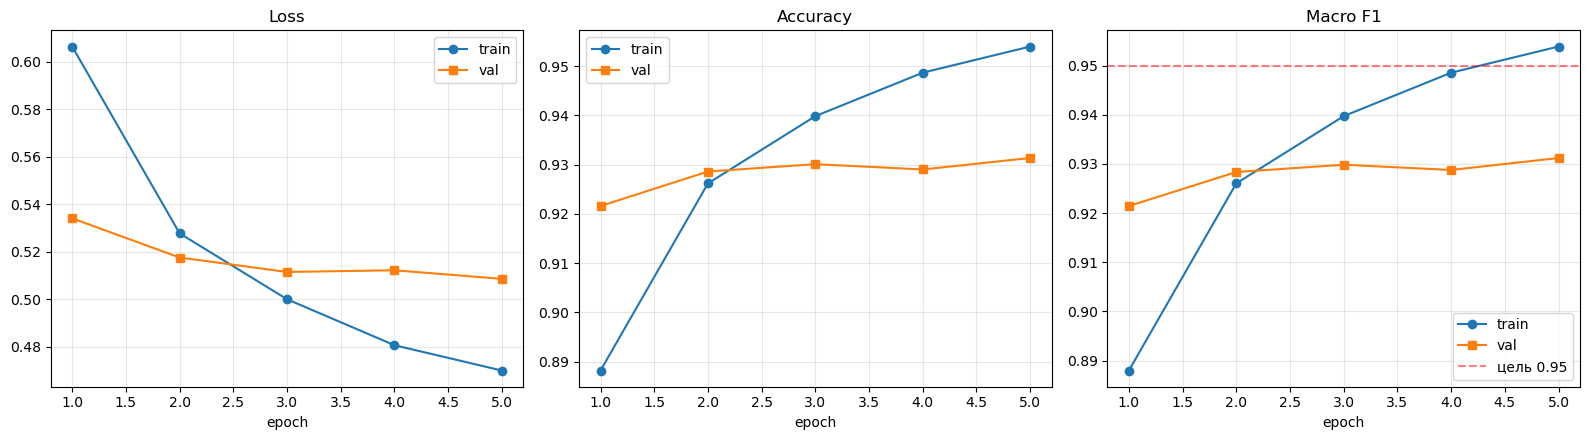

In [9]:
ep_axis = np.arange(1, EPOCHS+1)
fig, ax = plt.subplots(1, 3, figsize=(16, 4.5))
ax[0].plot(ep_axis, history['tr_loss'], 'o-', label='train')
ax[0].plot(ep_axis, history['val_loss'], 's-', label='val')
ax[0].set_title('Loss'); ax[0].set_xlabel('epoch'); ax[0].legend(); ax[0].grid(alpha=0.3)
ax[1].plot(ep_axis, history['tr_acc'], 'o-', label='train')
ax[1].plot(ep_axis, history['val_acc'], 's-', label='val')
ax[1].set_title('Accuracy'); ax[1].set_xlabel('epoch'); ax[1].legend(); ax[1].grid(alpha=0.3)
ax[2].plot(ep_axis, history['tr_f1'], 'o-', label='train')
ax[2].plot(ep_axis, history['val_f1'], 's-', label='val')
ax[2].axhline(0.95, color='r', ls='--', alpha=0.5, label='цель 0.95')
ax[2].set_title('Macro F1'); ax[2].set_xlabel('epoch'); ax[2].legend(); ax[2].grid(alpha=0.3)
plt.tight_layout(); plt.show()

## 10. Тест

In [10]:
model.eval()
all_p, all_t = [], []
with torch.no_grad():
    for x, msk, y in test_dl:
        x, msk = x.to(device), msk.to(device)
        all_p.append(model(x, msk).argmax(1).cpu().numpy())
        all_t.append(y.numpy())
all_p = np.concatenate(all_p); all_t = np.concatenate(all_t)

test_acc = accuracy_score(all_t, all_p)
test_f1  = f1_score(all_t, all_p, average='macro')
print(f'TEST accuracy = {test_acc:.4f}')
print(f'TEST macro F1 = {test_f1:.4f}')
print()
print(classification_report(all_t, all_p, target_names=CLASSES, digits=4))

TEST accuracy = 0.9263
TEST macro F1 = 0.9262

              precision    recall  f1-score   support

       World     0.9415    0.9142    0.9276      1900
      Sports     0.9621    0.9889    0.9753      1900
    Business     0.8939    0.8953    0.8946      1900
    Sci/Tech     0.9073    0.9068    0.9071      1900

    accuracy                         0.9263      7600
   macro avg     0.9262    0.9263    0.9262      7600
weighted avg     0.9262    0.9263    0.9262      7600



## 11. Confusion matrix

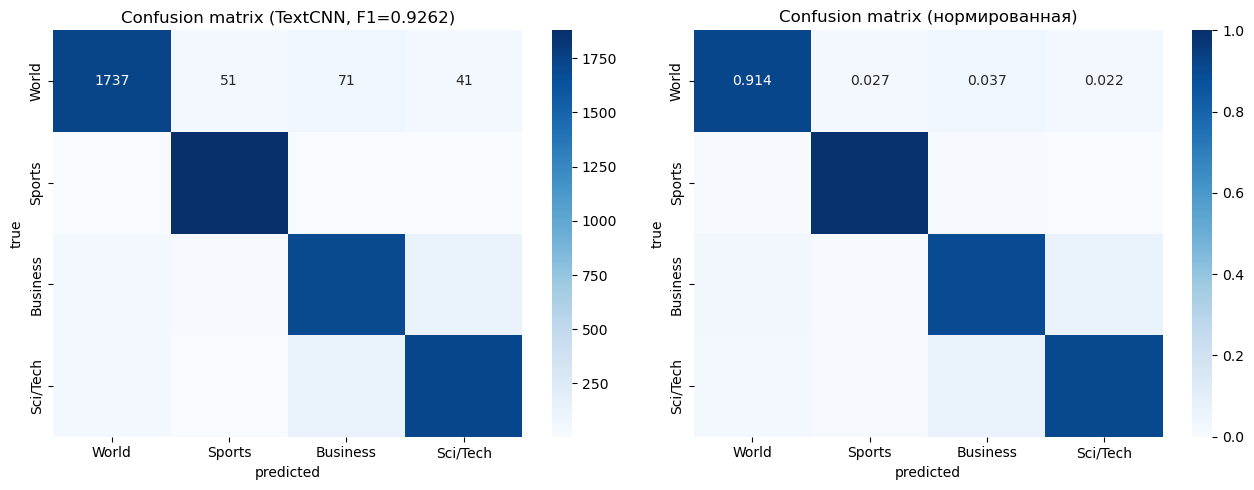

In [11]:
cm = confusion_matrix(all_t, all_p)
fig, ax = plt.subplots(1, 2, figsize=(13, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASSES, yticklabels=CLASSES, ax=ax[0])
ax[0].set_title(f'Confusion matrix (TextCNN, F1={test_f1:.4f})')
ax[0].set_xlabel('predicted'); ax[0].set_ylabel('true')
cmn = cm / cm.sum(axis=1, keepdims=True)
sns.heatmap(cmn, annot=True, fmt='.3f', cmap='Blues', vmin=0, vmax=1,
            xticklabels=CLASSES, yticklabels=CLASSES, ax=ax[1])
ax[1].set_title('Confusion matrix (нормированная)')
ax[1].set_xlabel('predicted'); ax[1].set_ylabel('true')
plt.tight_layout(); plt.show()

## 12. Разбор ошибок

In [12]:
errs = [(i, int(t), int(p)) for i, (t, p) in enumerate(zip(all_t, all_p)) if t != p]
print(f'ошибок: {len(errs)} / {len(all_t)}  ({len(errs)/len(all_t)*100:.2f}%)\n')

from collections import Counter as C
pairs = C((CLASSES[t], CLASSES[p]) for _, t, p in errs)
print('top-5 пар (true -> pred):')
for (t, p), c in pairs.most_common(5):
    print(f'  {t:>10} -> {p:<10}  {c}')

print('\nпримеры:')
for k, (i, t, p) in enumerate(errs[:5], 1):
    print(f'\n{k}. true={CLASSES[t]}, pred={CLASSES[p]}')
    print('  ', X_test[i][:200], '...')

ошибок: 560 / 7600  (7.37%)

top-5 пар (true -> pred):
    Business -> Sci/Tech    131
    Sci/Tech -> Business    122
       World -> Business    71
    Business -> World       55
       World -> Sports      51

примеры:

1. true=Sci/Tech, pred=Business
   Some People Not Eligible to Get in on Google IPO Google has billed its IPO as a way for everyday people to get in on the process, denying Wall Street the usual stranglehold it's had on IPOs. Public bi ...

2. true=Sci/Tech, pred=Business
   Rivals Try to Turn Tables on Charles Schwab By MICHAEL LIEDTKE     SAN FRANCISCO (AP) -- With its low prices and iconoclastic attitude, discount stock broker Charles Schwab Corp. (SCH) represented an  ...

3. true=World, pred=Business
   Venezuela Prepares for Chavez Recall Vote Supporters and rivals warn of possible fraud; government says Chavez's defeat could produce turmoil in world oil market. ...

4. true=Sci/Tech, pred=World
   Promoting a Shared Vision As Michael Kaleko kept running into p

## 13. Итог по TextCNN

TextCNN с GloVe-100 даёт хороший baseline, но к целевому 0.95 не дотягивает. На семинаре говорилось что для большего качества нужен либо длинный контекст (BiLSTM), либо более выразительные эмбеддинги.

Дальше в `agnews_hybrid.ipynb` буду навешивать BiLSTM поверх той же эмбеддинговой матрицы — то есть склеивать TextCNN-фичи (локальные n-граммы) с BiLSTM-фичами (длинный контекст), и кидать всё в общий MLP.